# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

# Question 1.1

Beskriv vad som ska beräknas

In [106]:
# Importing necessary packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Importing the DstApi class from the dstapi module and the Ronya_dataproject module as dp
from dstapi import DstApi

import Ronya_dataprojekt11 as dp

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


In [4]:
 # Using inner join to combine gini_clean and TOP10 into a new DataFrame called merged.
merged = pd.merge(
    dp.gini_clean,
    dp.TOP10,
    on='TID',
    how='inner',
    validate='1:1') 

merged = merged.rename(columns={'INDHOLD': 'TOP10'})

display(merged.head(100))

,TID,GINI,TOP10
0,1987,22.07,18.454866
1,1988,22.06,18.428870
2,1989,21.93,18.495170
3,1990,22.16,18.641480
4,1991,21.99,18.668346
5,1992,22.34,18.824050
6,1993,22.79,19.213004
7,1994,22.50,19.082992
8,1995,22.41,19.296649
9,1996,22.83,19.613977


We process the data by ...

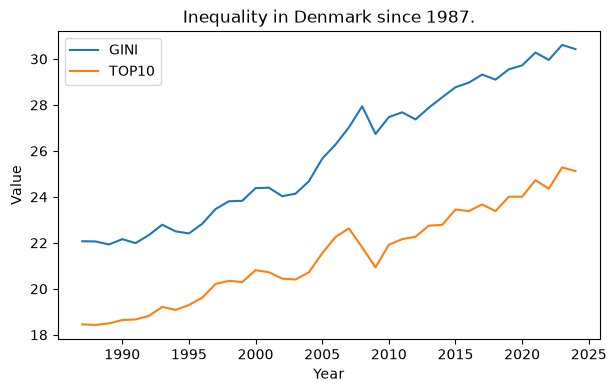

In [5]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(merged['TID'], merged['GINI'], label='GINI')
ax.plot(merged['TID'], merged['TOP10'], label='TOP10')


ax.set_title('Inequality in Denmark since 1987.')
ax.set_xlabel('Year')
ax.set_ylabel('Value')

ax.legend();

In [6]:
# Calculation of correlation between GINI and TOP10

correlation = merged['GINI'].corr(merged['TOP10'])
print(f'Correlation between GINI and TOP10: {correlation:.6f}')

Correlation between GINI and TOP10: 0.981642


We find that that ...

## Question 1.2

In [29]:
# Defining t and y

t = merged['TID'] - 1987
y = merged['GINI']

# Calculating linear 
def s_linear(beta):
    y_prediction = beta[0] + beta[1] * t
    sum = ((y - y_prediction) ** 2).sum()

    return sum

from scipy.optimize import minimize

result_linear = minimize(s_linear, [0, 0])

result_linear.x

array([21.04275355,  0.26354959])

In [30]:
# Calculating quadratic 
def s_quadratic(beta):
    y_prediction = beta[0] + beta[1]* t + beta[2] * t**2
    sum = ((y - y_prediction) ** 2).sum()

    return sum
    
from scipy.optimize import minimize
    
result_quadratic = minimize(s_quadratic, [0, 0, 0])
    
result_quadratic.x

array([2.13041867e+01, 2.19975902e-01, 1.17767450e-03])

In [ ]:
# Calculating and comparing with np.polyfit for: 

# a) linear
print(np.polyfit(t, y, 1))

# b) quadratic
print(np.polyfit(t, y, 2))


[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


In [ ]:
# Predicting the Gini coefficient in 2030 for:

t_2030 = 2030 - 1987

# a) linear

def s_linear_2030(beta):
    gini_linear_2030 =  beta[0] + beta[1] * t_2030

    return gini_linear_2030

print("Linear Gini in 2030 is:", s_linear_2030(result_linear.x))

# b) quadratic
def s_quadratic_2030(beta):
    gini_quadratic_2030 =  beta[0] + beta[1] * t_2030 + beta[2] * t_2030 **2

    return gini_quadratic_2030

print("Quadratic Gini in 2030 is:", s_quadratic_2030(result_quadratic.x))



Linear Gini in 2030 is: 32.37538611098807
Quadratic Gini in 2030 is: 32.94067063473604


In [43]:
# Predicting the Gini coefficient in 2040 for:

t_2040 = 2040 - 1987

# a) linear

def s_linear_2040(beta):
    gini_linear_2040 =  beta[0] + beta[1] * t_2040

    return gini_linear_2040

print("Linear Gini in 2040 is:", s_linear_2040(result_linear.x))

# b) quadratic
def s_quadratic_2040(beta):
    gini_quadratic_2040 =  beta[0] + beta[1] * t_2040 + beta[2] * t_2040 **2

    return gini_quadratic_2040

print("Quadratic Gini in 2040 is:", s_quadratic_2040(result_quadratic.x))


Linear Gini in 2040 is: 35.01088205439406
Quadratic Gini in 2040 is: 36.270997179924024


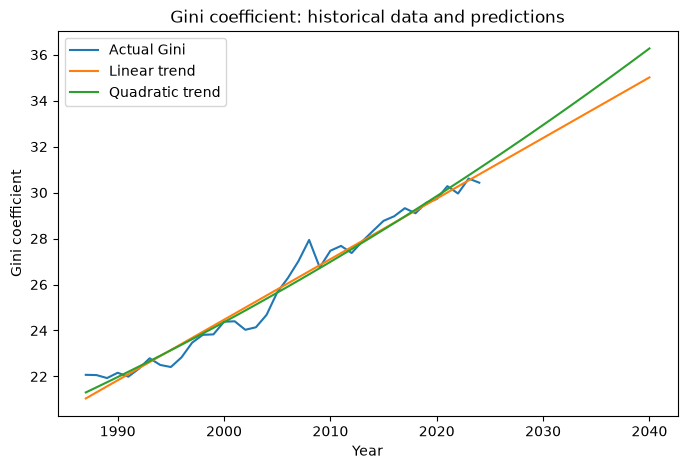

In [ ]:
# Plotting the values  
years_plot = np.arange(1987, 2041)
t_plot = years_plot - 1987

beta_linear = result_linear.x
beta_quadratic = result_quadratic.x

gini_linear_plot = beta_linear[0] + beta_linear[1] * t_plot

gini_quadratic_plot = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

# Plotting the results 
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(merged['TID'], merged['GINI'], label='Actual Gini')
ax.plot(years_plot, gini_linear_plot, label='Linear trend')
ax.plot(years_plot, gini_quadratic_plot, label='Quadratic trend')

ax.set_title('Gini coefficient: historical data and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

ax.legend()

Question 1.3

In [186]:
import Ronya_dataproject13 

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


In [187]:
# Correlation between gini and Top10 incomers for municipalities
correlation_municipalities = merged_municipalities['GINI'].corr(
    merged_municipalities['TOP10']
)

print(f'Correlation between the munucipalities GINI and TOP10: {correlation_municipalities:.6f}')

Correlation between the munucipalities GINI and TOP10: 0.960545


In [188]:
#Convert GINI to numeric
gini_municipalities['GINI'] = pd.to_numeric(gini_municipalities['GINI'])

# Find the most recent year
recent_year = gini_municipalities['TID'].max()

# Keep observations from the most recent year
data_for_2024 = gini_municipalities[
    gini_municipalities['TID'] == recent_year
]

# Find the 10 municipalities with the highest Gini
most_unequal = data_for_2024.nlargest(10, 'GINI')

print("The top 10 most unequal municipalites are:")
display(most_unequal)

# Find the 10 municipalites with the lowest Gini
most_equal = data_for_2024.nsmallest(10, 'GINI')

print("")
print("The top 10 most equal municipalites are:")
display(most_equal)


The top 10 most unequal municipalites are:


,KOMMUNEDK,TID,GINI
3471,Gentofte,2024,49.04
3489,Rudersdal,2024,47.31
3529,Vejen,2024,46.32
3488,Hørsholm,2024,40.07
3478,Lyngby-Taarbæk,2024,39.28
3467,Frederiksberg,2024,36.54
3466,Copenhagen,2024,34.97
3547,Aarhus,2024,33.43
3485,Fredensborg,2024,32.76
3486,Helsingør,2024,30.55



The top 10 most equal municipalites are:


,KOMMUNEDK,TID,GINI
3514,Faaborg-Midtfyn,2024,23.77
3490,Egedal,2024,23.85
3511,Bornholm,2024,24.03
3500,Faxe,2024,24.09
3494,Halsnæs,2024,24.41
3541,Favrskov,2024,24.41
3513,Assens,2024,24.46
3550,Hedensted,2024,24.58
3475,Albertslund,2024,24.66
3542,Odder,2024,24.70


The least equal:


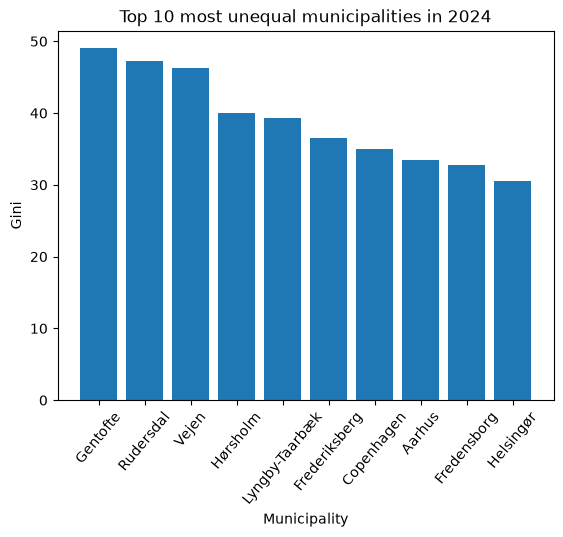


The most equal:


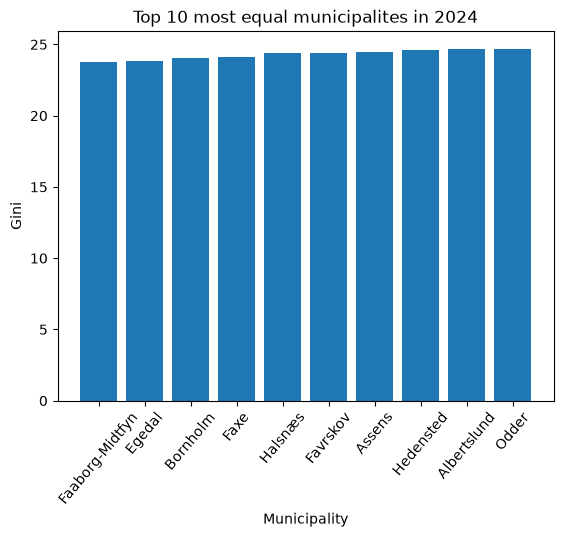

In [189]:
# Plotting the data into figures:

# a) for the 10 most unequal
plt.bar(most_unequal['KOMMUNEDK'], most_unequal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most unequal municipalities in 2024')

plt.xticks(rotation = 50)

print('The least equal:')
plt.show()

# b) for the 10 most equal
plt.bar(most_equal['KOMMUNEDK'], most_equal['GINI'])

plt.xlabel('Municipality')
plt.ylabel('Gini')
plt.title('Top 10 most equal municipalites in 2024')

plt.xticks(rotation = 50)

print('')
print('The most equal:')
plt.show()